# Algoritmo Genético Simple

## Función a maximizar

$f(x)=\left[1-\left(\frac{11}{2}x-\frac{7}{2}\right)^2\right]\left[\cos\left(\frac{11}{2}x-\frac{7}{2}\right)+1\right]+2$


In [11]:
# Valores de las variables
import numpy as np
import matplotlib.pyplot as plt

Nind = 5
Lind = 20
Pc = 0.70
Pm = 1/15
Maxgen = 100
Nvar = 1
rango = np.array([[0.0, 0.875]])

## A continuación, se desarrollan las funciones del algoritmo genético:


### `creapob`

In [12]:
def creapob(Nind, Lind):
    return np.random.randint(0, 2, size=(Nind, Lind))

### `decodifica`

In [13]:
def decodifica(genotipo, rango):
    Nvar = rango.shape[0]
    Nind, Lind = genotipo.shape

    bits_por_var = np.full(Nvar, Lind // Nvar, dtype=int)
    bits_por_var[: Lind % Nvar] += 1

    fenotipo = np.zeros((Nind, Nvar))
    inicio = 0

    for j, Lvar in enumerate(bits_por_var):
        fin = inicio + Lvar
        subcadena = genotipo[:, inicio:fin]
        potencias = 2 ** np.arange(Lvar - 1, -1, -1)
        decimal = subcadena @ potencias
        li, ls = rango[j]
        fenotipo[:, j] = li + ((ls - li) / (2 ** Lvar - 1)) * decimal
        inicio = fin

    return fenotipo


La codificación de las variables responde a las siguientes fórmulas.

Esto significa que de la cadena binaria a las variables de decisión en el dominio del problema, se procede a evaluar la función para obtener su valor objetivo.


### `objfun`

In [14]:
def objfun(fenotipo):
    Nind, Nvar = fenotipo.shape
    objv = np.zeros((Nind, 1))

    for i in range(Nind):
        x = fenotipo[i, 0]
        objv[i, 0] = (1 - (((11 / 2) * x) - (7 / 2)) ** 2) * (np.cos(((11 / 2) * x) - (7 / 2)) + 1) + 2

    return objv

### `rankeo`

In [15]:
def rankeo(objv, direccion):
    SP = 2
    Nind, _ = objv.shape
    aptitud = np.zeros((Nind, 1))

    if direccion == 1:
        posori = np.argsort(objv[:, 0])
    else:
        posori = np.argsort(-objv[:, 0])

    apt = 2 - SP + 2 * (SP - 1) * (np.arange(Nind) / (Nind - 1))
    aptitud[posori, 0] = apt

    return aptitud

### `ruleta`

In [16]:
def ruleta(genotipo, fenotipo, aptitud):
    Nind, aux = aptitud.shape
    total = np.sum(aptitud)
    probabilidad = aptitud / total
    acumulada = np.cumsum(probabilidad)
    idx = np.zeros((Nind, 1), dtype=int)

    for i in range(Nind):
        selecciona = np.random.rand()
        aux = np.where(acumulada >= selecciona)[0]
        idx[i, 0] = aux[0]

    nuevo_gen = genotipo[idx.flatten(), :]

    return nuevo_gen

### `xunpunto`

In [17]:
def xunpunto(nuevo_gen, Pc):
    Nind, Lind = nuevo_gen.shape
    aux_gen = nuevo_gen.copy()
    par = Nind % 2

    for i in range(0, Nind - 1, 2):
        cruza = np.random.rand()
        if cruza <= Pc:
            corte = np.random.randint(1, Lind)
            aux_gen[i, :] = np.concatenate((nuevo_gen[i, :corte], nuevo_gen[i + 1, corte:]))
            aux_gen[i + 1, :] = np.concatenate((nuevo_gen[i + 1, :corte], nuevo_gen[i, corte:]))
        else:
            aux_gen[i, :] = nuevo_gen[i, :]
            aux_gen[i + 1, :] = nuevo_gen[i + 1, :]

    if par == 1:
        aux_gen[Nind - 1, :] = nuevo_gen[Nind - 1, :]

    return aux_gen

### `muta`

In [18]:
def muta(nuevo_gen, Pm):
    Nind, Lind = nuevo_gen.shape
    valores = np.random.rand(Nind, Lind)
    mascara = valores <= Pm
    nuevo_gen = np.logical_xor(nuevo_gen, mascara).astype(int)

    return nuevo_gen

## 2. Crear la población inicial

Se crean los nodos (individuos) de la población de forma aleatoria, que son el espacio de soluciones potenciales para resolver la función objetivo. Cada nodo debe decodificarse a binario.


In [19]:
genotipo = creapob(Nind, Lind)
fenotipo = decodifica(genotipo, rango)

## 3. Obteniendo el valor óptimo

El valor óptimo corresponde al “mejor valor” encontrado en la función objetivo, así como las variables que permitieron encontrarlo.


In [20]:
Mejor = np.full((Maxgen, 1), np.nan)  # Referencia al mejor valor óptimo encontrado de la función objetivo
Mejor_cromosoma = np.zeros((Maxgen, Lind), dtype=int)  # Mejor cromosoma encontrado por cada generación
objv = objfun(fenotipo)  # evaluación de la función

idx0 = np.argmax(objv)
Mejor[0] = objv[idx0]
Mejor_cromosoma[0, :] = genotipo[idx0, :]

## 4. Ciclo Evolutivo

Una vez creada y evaluada la población inicial, se procede al ciclo evolutivo.


In [26]:
generaciones = 5

while generaciones < Maxgen:  # Número de generaciones predefinidas
    aptitud = rankeo(objv, 1)  # cada generación se establece el fitness para cada solución encontrada
    nuevo_gen = ruleta(genotipo, fenotipo, aptitud)
    nuevo_gen = xunpunto(nuevo_gen, Pc)
    nuevo_gen = muta(nuevo_gen, Pm)

    nuevo_feno = decodifica(nuevo_gen, rango)
    nuevo_objv = objfun(nuevo_feno)

    genotipo = nuevo_gen
    fenotipo = nuevo_feno
    objv = nuevo_objv

    idx = np.argmax(objv)
    Mejor[generaciones] = objv[idx]
    Mejor_cromosoma[generaciones, :] = genotipo[idx, :]
    generaciones += 1

Agregar el código necesario para almacenar las mejores soluciones de cada generación e imprimir el mejor valor de todas las generaciones.


In [27]:
idx_mejor = np.nanargmax(Mejor[:, 0])
mejor_valor = float(Mejor[idx_mejor, 0])
mejor_cromosoma = Mejor_cromosoma[idx_mejor, :].astype(int)
mejor_fenotipo = decodifica(mejor_cromosoma.reshape(1, -1), rango)[0]

print(f'Mejor generación: {idx_mejor}')
print(f'Mejor valor encontrado: {mejor_valor:.6f}')
print(f'Mejor cromosoma: {mejor_cromosoma}')
print(f'Mejor solución (x): {mejor_fenotipo[0]:.6f}')

Mejor generación: 99
Mejor valor encontrado: 3.990558
Mejor cromosoma: [1 0 1 1 0 1 1 0 1 1 1 0 1 0 0 1 0 1 0 0]
Mejor solución (x): 0.625185


## Resultado esperado

Implemente el código necesario para su graficación.

Replique el código anterior, agregando las librerías que hagan falta.

Compare los resultados con la programación estructurada (sin AG) que a continuación se muestra:


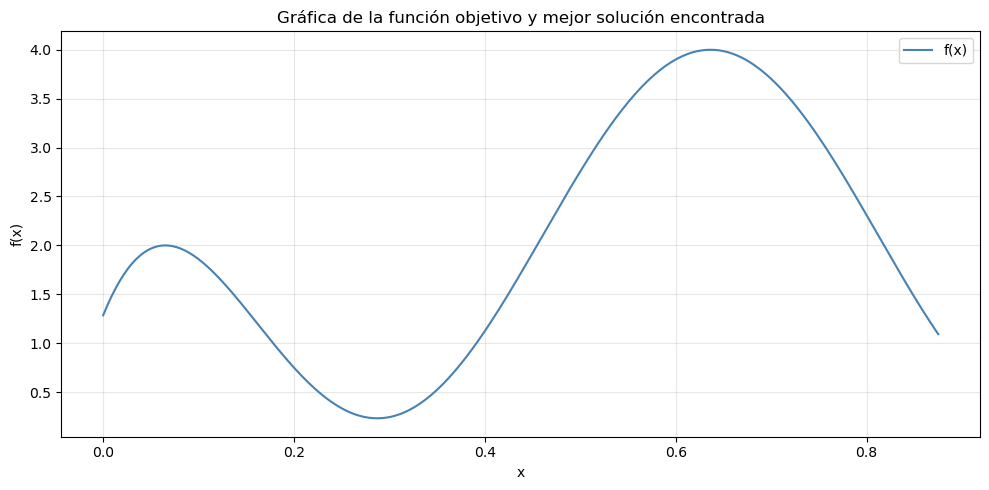

In [28]:
import matplotlib.pyplot as plt

x = np.linspace(rango[0, 0], rango[0, 1], 400)
feno_malla = x.reshape(-1, 1)
z = objfun(feno_malla).flatten()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, z, color='steelblue', label='f(x)')

# Usar la mejor solución global encontrada por el GA
x_mejor = mejor_fenotipo[0]
z_mejor = mejor_valor

ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Gráfica de la función objetivo y mejor solución encontrada')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()